# 1. Data Loading
---
This notebook is intended to be run both locally and on kaggle. Therefore, it needs accomodates the different data sources when loading the csvs. Before handling the data, imports will all be coalesced into a specified subsection.



## 1.1 Imports

In [1]:
"""Student health risk prediction notebook."""
import os
import optuna
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, balanced_accuracy_score


# 1.2 Data loading

In [ ]:
# 1. Automatically detect the environment
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    # Settings optimized for Kaggle's NVIDIA GPUs
    TREE_METHOD = "hist"  # XGBoost
    DEVICE_TYPE = "gpu"  # LightGBM (Kaggle uses OpenCL 'gpu', not 'cuda')
    CAT_TASK_TYPE = "GPU"  # CatBoost
    print("Environment: Kaggle (NVIDIA GPU Enabled)")
else:
    # Settings optimized for the local environment
    TREE_METHOD = "hist"  # XGBoost (Uses Metal/MPS natively via hist)
    DEVICE_TYPE = "cpu"  # LightGBM (Standard Mac wheels lack GPU support)
    CAT_TASK_TYPE = "CPU"  # CatBoost (Mac GPU support is experimental; CPU is faster)
    print("Environment: Local Mac (CPU fallback for LightGBM/CatBoost)")

Environment: Local Mac (CPU fallback for LightGBM/CatBoost)


In [3]:
def load_data():
    """
    try to load the data from the local directory, if not found, load it from the Kaggle dataset.
    Output the three dataframes: train, test, and submission.
    """

    if IS_KAGGLE:
        # check if the data files are in kaggle direcotry
        # /kaggle/input/competitions/playground-series-s6e7
        print("Trying to load data from kaggle input directory...")
        train = pd.read_csv(
            "/kaggle/input/competitions/playground-series-s6e7/train.csv"
        )
        test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")
        submission = pd.read_csv(
            "/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv"
        )
        print("Data loaded successfully from kaggle input directory.")
    else:
        print("Trying to load data from local directory...")
        # Load data from local directory
        data_dir = os.getcwd() + "/data/"
        train = pd.read_csv(data_dir + "train.csv")
        test = pd.read_csv(data_dir + "test.csv")
        submission = pd.read_csv(data_dir + "sample_submission.csv")
        print("Data loaded successfully from local directory.")

    return train, test, submission

In [4]:
train_df, test_df, submission_df = load_data()

Trying to load data from local directory...
Data loaded successfully from local directory.


# 2. Data exploration
---
Having organised the data into dataframes that can be explored and prepared for preprocessing, the necessary quality checks can be done. In this section, we will explore the data for missing values, extreme values and mislabelled data types. 

## 2.1 Check for missing values/null values

In [5]:
def check_missing_values(df):
    """
    Check for missing values in the dataframe and print the count of missing values for each column.
    """
    temp_df = df.copy()
    # check if the dataframe is empty
    if temp_df.empty:
        print("The dataframe is empty. No missing values to check.")
        return
    # check that the dataframe has missing values
    if temp_df.isnull().sum().sum() == 0:
        print("The dataframe has no missing values.")
        return
    # Iterate through each column and check the number of missing values
    for column in temp_df.columns:
        missing_count = temp_df[column].isnull().sum()
        if missing_count > 0:
            # print column name
            # number of missing values againts total number of rows in the column
            total_rows = temp_df.shape[0]
            print(
                f"{column:<25}"
                f"Missing Values: {missing_count:<10}"
                f"Total Rows: {total_rows:<10}"
                f"Percentage Missing: {missing_count / total_rows * 100:.2f}%"
            )

In [6]:
check_missing_values(train_df)


sleep_duration           Missing Values: 75999     Total Rows: 690088    Percentage Missing: 11.01%
heart_rate               Missing Values: 7833      Total Rows: 690088    Percentage Missing: 1.14%
bmi                      Missing Values: 13898     Total Rows: 690088    Percentage Missing: 2.01%
calorie_expenditure      Missing Values: 52853     Total Rows: 690088    Percentage Missing: 7.66%
step_count               Missing Values: 13916     Total Rows: 690088    Percentage Missing: 2.02%
exercise_duration        Missing Values: 6901      Total Rows: 690088    Percentage Missing: 1.00%
water_intake             Missing Values: 43477     Total Rows: 690088    Percentage Missing: 6.30%
diet_type                Missing Values: 6901      Total Rows: 690088    Percentage Missing: 1.00%
stress_level             Missing Values: 82811     Total Rows: 690088    Percentage Missing: 12.00%
sleep_quality            Missing Values: 58331     Total Rows: 690088    Percentage Missing: 8.45%
physical

In [7]:
check_missing_values(test_df)

sleep_duration           Missing Values: 32571     Total Rows: 295753    Percentage Missing: 11.01%
heart_rate               Missing Values: 3357      Total Rows: 295753    Percentage Missing: 1.14%
bmi                      Missing Values: 5956      Total Rows: 295753    Percentage Missing: 2.01%
calorie_expenditure      Missing Values: 22652     Total Rows: 295753    Percentage Missing: 7.66%
step_count               Missing Values: 5964      Total Rows: 295753    Percentage Missing: 2.02%
exercise_duration        Missing Values: 2958      Total Rows: 295753    Percentage Missing: 1.00%
water_intake             Missing Values: 18633     Total Rows: 295753    Percentage Missing: 6.30%
diet_type                Missing Values: 2958      Total Rows: 295753    Percentage Missing: 1.00%
stress_level             Missing Values: 35490     Total Rows: 295753    Percentage Missing: 12.00%
sleep_quality            Missing Values: 24999     Total Rows: 295753    Percentage Missing: 8.45%
physical

Even though there is missing data in the train dataset. The presence of missing data in the test data could mean mimicry of real world challenges face, therefore the next sections will explore ways to elegantly form predictions with the presence of missing data.

## 2.2 Class imbalance check

In [8]:
def check_class_imbalance(df):
    """
    Check for class imbalance.
    Plots distribution of target variables.
    target column is assumed to always be health_condition as from competition details.

    Input-
    df: pandas dataframe

    Output-
    None

    """

    # check if the dataframe is empty
    if df.empty:
        print("The dataframe is empty. No class imbalance to check.")
        return

    # check if the target column exists
    if "health_condition" not in df.columns:
        print("The target column 'health_condition' does not exist in the dataframe.")
        return

    # check if the target column has more than one class
    if df["health_condition"].nunique() <= 1:
        print(
            "The target column 'health_condition' has only one class. No class imbalance to check."
        )
        return

    # Plot grid of multiple different plots to visualize class imbalance
    plt.figure(figsize=(15, 10))
    # Add title to the grid of plots
    plt.suptitle("Health Condition Imbalance Visualization", fontsize=16)

    # Plot horizontal bar chart of health condition with counts of samples
    plt.subplot(2, 2, 1)
    ax = sns.countplot(
        data=df,
        y="health_condition",
        order=df["health_condition"].value_counts().index,
        hue="health_condition",
        palette=sns.color_palette("Set2", df["health_condition"].nunique()),
    )
    # add value counts to the bars
    for container in ax.containers:
        ax.bar_label(
            container,
            label_type="center",
        )

    # Plot pie chart of target variable with percentage of samples in each class
    plt.subplot(2, 2, 2)
    df["health_condition"].value_counts().plot.pie(
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("Set2", df["health_condition"].nunique()),
    )
    plt.title("Pie Chart of Health Condition")
    # add legend to the pie chart and place it outside the pie chart
    plt.legend(
        labels=df["health_condition"].value_counts().index,
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize=10,
    )

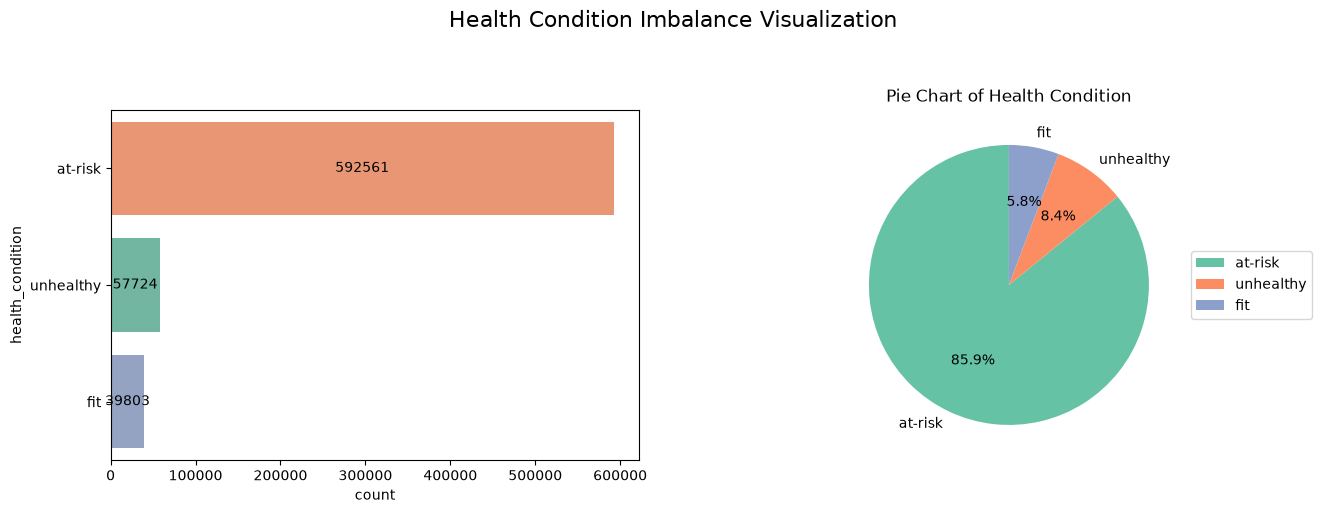

In [9]:
check_class_imbalance(train_df)

From the above, it can be seen that the dataset is imbalanced. `At-risk` label has around *85%* of the samples while `fit` and `unhealthy` are at *5.7%* and *8.5%* respectively. 

# 3. Data Preprocessing

## 3.1 Addressing the `id` column 
The `id` column is of no use in prediction and could possible be detrimental to the accuracy of the predictions. To prevent any negative effects setting the columns as the index would indicate to the model and processing functions that the column should be excluded.

In [10]:
train_df.set_index("id", inplace=True)
test_df.set_index("id", inplace=True)

## 3.2 Encoding categorical columns

In [11]:
# encoding the target variable
le = LabelEncoder()
y_train = le.fit_transform(train_df["health_condition"])

# Convert categorical string features to pandas 'category' data type
categorical_cols = train_df.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:
    if col != "health_condition":  # Skip target since it's already separated
        train_df[col] = train_df[col].astype("category")
        test_df[col] = test_df[col].astype("category")

# Separate features from the training set
X_train = train_df.drop(columns=["health_condition"])

## 3.3 Validation split

In [12]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,  # Crucial for the imbalanced dataset
    random_state=42,
)

# 4. Model(Xgboost)

## 4.1 Hyperparameter Tuning with Optuna
To maximize predictive performance, Bayesian optimization via Optuna is used to find the optimal hyperparameter configuration for the XGBoost model. The search space explores learning rates, tree depth, and regularization parameters.

In [13]:
# Compute sample weights to counter the 85% / 8.5% / 5.7% class imbalance
sample_weights = compute_sample_weight(class_weight="balanced", y=y_tr)


def objective(trial):
    # Define the search space
    params = {
        "objective": "multi:softmax",
        "num_class": 3,
        "tree_method": TREE_METHOD,  # Dynamically uses the environment variable
        "n_jobs": 1,  # CRITICAL: Prevent thread contention during parallel trials
        "enable_categorical": True,
        "missing": np.nan,
        "eval_metric": "mlogloss",
        "random_state": 42,
        "early_stopping_rounds": 50,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 7),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
    }

    model = xgb.XGBClassifier(**params)

    # Fit the model using the validation set
    model.fit(
        X_tr,
        y_tr,
        sample_weight=sample_weights,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    y_pred = model.predict(X_val)

    # Use balanced accuracy as the optimization metric due to class imbalance
    return balanced_accuracy_score(y_val, y_pred)


# Create and run the study
# n_jobs=-1 utilizes all available cores for parallel trial execution
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, n_jobs=-1)

print(f"Best trial balanced accuracy: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)

[I 2026-07-30 16:06:06,970] A new study created in memory with name: no-name-fce2f845-499f-4910-9de5-6628a37fd60e
[I 2026-07-30 16:06:18,492] Trial 8 finished with value: 0.941939556441118 and parameters: {'learning_rate': 0.005714607065493739, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.6518083032089972, 'colsample_bytree': 0.9479441028617142, 'gamma': 0.00023687664868670669}. Best is trial 8 with value: 0.941939556441118.
[I 2026-07-30 16:06:20,997] Trial 9 finished with value: 0.9311969701070595 and parameters: {'learning_rate': 0.001879808178868382, 'max_depth': 4, 'min_child_weight': 7, 'subsample': 0.8908409712425098, 'colsample_bytree': 0.514283906857783, 'gamma': 0.48769846182145143}. Best is trial 8 with value: 0.941939556441118.
[I 2026-07-30 16:06:21,006] Trial 5 finished with value: 0.9490996298374719 and parameters: {'learning_rate': 0.11094433306785723, 'max_depth': 4, 'min_child_weight': 5, 'subsample': 0.7759739212261472, 'colsample_bytree': 0.5905124004148677

Best trial balanced accuracy: 0.9500
Best hyperparameters: {'learning_rate': 0.08161182965910618, 'max_depth': 7, 'min_child_weight': 3, 'subsample': 0.721196189036651, 'colsample_bytree': 0.7530633396238805, 'gamma': 1.5615956553103532e-07}


## 4.2 Final Model Training (5-Fold Cross-Validation)
Using the best parameters discovered by Optuna, the final model is trained using a 5-Fold Stratified Cross-Validation loop. This ensures the model learns from 100% of the training data while generating out-of-fold (OOF) predictions for unbiased evaluation and threshold tuning. Test set predictions are averaged across all 5 folds to reduce variance.

In [14]:
# 1. Setup arrays to hold Out-Of-Fold (OOF) probabilities and averaged test probabilities
# We use the full X_train and y_train variables established in Section 3.2
oof_probs = np.zeros((len(X_train), 3))
test_probs_cv = np.zeros((len(test_df), 3))

# 2. Initialize Stratified K-Fold (5 folds is standard)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Extract best parameters from Optuna (assumes 'study' exists from Section 4.1)
best_params = study.best_params
best_params.update(
    {
        "objective": "multi:softmax",
        "num_class": 3,
        "tree_method": TREE_METHOD,
        "n_jobs": -1,  # Safely use all cores for individual fold training
        "enable_categorical": True,
        "missing": np.nan,
        "eval_metric": "mlogloss",
        "random_state": 42,
        "early_stopping_rounds": 50,
    }
)

print("Starting 5-Fold Stratified Cross-Validation...")
print("-" * 40)

# 4. Iterate through each fold
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"Training Fold {fold + 1}/5...")

    # Split data into fold-specific train and validation sets
    X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train[train_idx]
    X_fold_val, y_fold_val = X_train.iloc[val_idx], y_train[val_idx]

    # Compute sample weights dynamically for the current fold's training data
    fold_weights = compute_sample_weight(class_weight="balanced", y=y_fold_train)

    # Instantiate and fit the model
    fold_model = xgb.XGBClassifier(**best_params)
    fold_model.fit(
        X_fold_train,
        y_fold_train,
        sample_weight=fold_weights,
        eval_set=[(X_fold_val, y_fold_val)],
        verbose=False,  # Suppressed to keep output clean
    )

    # Store the OOF probabilities for this fold's validation set
    oof_probs[val_idx] = fold_model.predict_proba(X_fold_val)

    # Accumulate the test set probabilities (divided by 5 to safely average them)
    test_probs_cv += fold_model.predict_proba(test_df) / skf.n_splits

print("-" * 40)
print("Cross-Validation Complete!")

Starting 5-Fold Stratified Cross-Validation...
----------------------------------------
Training Fold 1/5...
Training Fold 2/5...
Training Fold 3/5...
Training Fold 4/5...
Training Fold 5/5...
----------------------------------------
Cross-Validation Complete!


## 4.3 Model Evaluation

OOF Balanced Accuracy: 0.9496
------------------------------


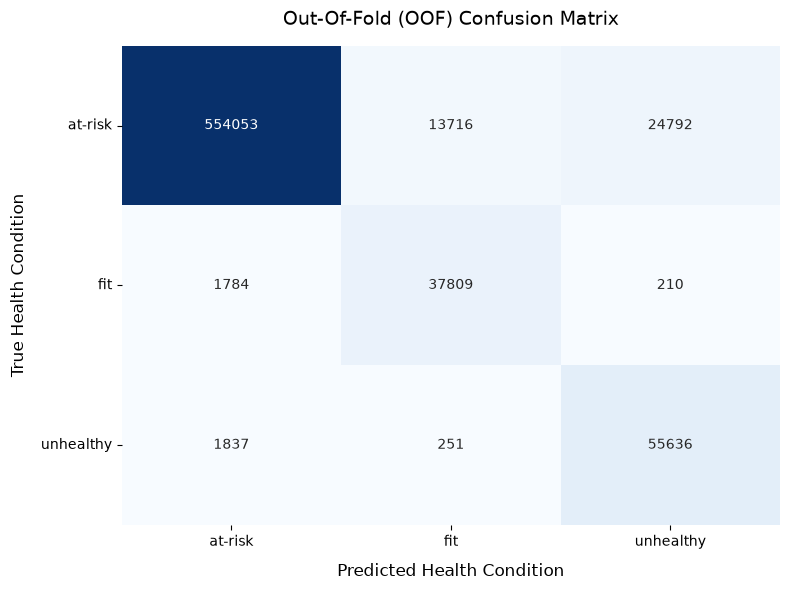

--- The Confusion Matrix (Text Version) ---
                 Pred: at-risk  Pred: fit  Pred: unhealthy
True: at-risk           554053      13716            24792
True: fit                 1784      37809              210
True: unhealthy           1837        251            55636


--- OOF Classification Report ---
              precision    recall  f1-score   support

     at-risk       0.99      0.94      0.96    592561
         fit       0.73      0.95      0.83     39803
   unhealthy       0.69      0.96      0.80     57724

    accuracy                           0.94    690088
   macro avg       0.80      0.95      0.86    690088
weighted avg       0.95      0.94      0.94    690088



In [15]:
# Generate hard class predictions from the out-of-fold probabilities
oof_preds = np.argmax(oof_probs, axis=1)

# Calculate Balanced Accuracy across the entire training set
bal_acc = balanced_accuracy_score(y_train, oof_preds)
print(f"OOF Balanced Accuracy: {bal_acc:.4f}")
print("-" * 30)

# Generate the confusion matrix using OOF predictions
cm = confusion_matrix(y_train, oof_preds)

# Visualize with a seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)

plt.title("Out-Of-Fold (OOF) Confusion Matrix", fontsize=14, pad=15)
plt.xlabel("Predicted Health Condition", fontsize=12, labelpad=10)
plt.ylabel("True Health Condition", fontsize=12, labelpad=10)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Text Evaluation
cm_text = pd.DataFrame(
    cm,
    index=[f"True: {cls}" for cls in le.classes_],
    columns=[f"Pred: {cls}" for cls in le.classes_],
)

print("--- The Confusion Matrix (Text Version) ---")
print(cm_text)
print("\n" + "=" * 45 + "\n")

print("--- OOF Classification Report ---")
report = classification_report(y_train, oof_preds, target_names=le.classes_)
print(report)

## 4.4 Threshold Tuning (Probability Calibration)
To further improve precision on the minority classes, SciPy is used to optimize the decision threshold weights. By scaling the output probabilities before applying the `argmax` function, the model's cutoffs are calibrated to maximize the balanced accuracy score.

In [16]:
# 1. Define the objective function for SciPy to minimize using OOF probabilities
def threshold_objective(weights):
    # Scale probabilities by the weights and get the new predicted class
    weighted_probs = oof_probs * weights
    y_pred_tuned = np.argmax(weighted_probs, axis=1)

    # SciPy minimizes, so we return the negative balanced accuracy
    return -balanced_accuracy_score(y_train, y_pred_tuned)


# 2. Set initial weights and bounds
initial_weights = [1.0, 1.0, 1.0]
bounds = [(0.01, 10.0), (0.01, 10.0), (0.01, 10.0)]

# 3. Run the optimization using the Nelder-Mead algorithm
result = minimize(
    threshold_objective, initial_weights, bounds=bounds, method="Nelder-Mead"
)

best_weights = result.x
print(f"Optimal Class Weights [at-risk, fit, unhealthy]: {best_weights}")

# 4. Evaluate the tuned predictions on the full training set
y_pred_tuned = np.argmax(oof_probs * best_weights, axis=1)
tuned_bal_acc = balanced_accuracy_score(y_train, y_pred_tuned)

print(f"Tuned OOF Balanced Accuracy: {tuned_bal_acc:.4f}")
print("-" * 30)
print("--- Tuned OOF Classification Report ---")
print(classification_report(y_train, y_pred_tuned, target_names=le.classes_))

Optimal Class Weights [at-risk, fit, unhealthy]: [0.96580694 1.05619781 0.97197266]
Tuned OOF Balanced Accuracy: 0.9496
------------------------------
--- Tuned OOF Classification Report ---
              precision    recall  f1-score   support

     at-risk       0.99      0.93      0.96    592561
         fit       0.73      0.95      0.82     39803
   unhealthy       0.69      0.96      0.80     57724

    accuracy                           0.94    690088
   macro avg       0.80      0.95      0.86    690088
weighted avg       0.95      0.94      0.94    690088



# 5. Model (LightGBM)
---
## 5.1 Hyperparameter Tuning with Optuna
We train a LightGBM classifier to ensemble with our XGBoost model. LightGBM builds trees leaf-wise rather than depth-wise, providing a diverse set of predictions. Optuna is used to maximize the balanced accuracy on our validation split.

In [17]:
warnings.filterwarnings(
    "ignore", category=UserWarning
)  # Suppresses LightGBM categorical warnings


def lgb_objective(trial):
    # Define the LightGBM search space
    params = {
        "objective": "multiclass",
        "num_class": 3,
        "metric": "multi_logloss",
        "device_type": DEVICE_TYPE,
        "n_jobs": 1,  # Prevent thread contention during parallel trials
        "random_state": 42,
        "n_estimators": 2000,  # High limit, early stopping will catch it
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "num_leaves": trial.suggest_int("num_leaves", 15, 100),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "verbose": -1,
    }

    # Instantiate the model
    model = lgb.LGBMClassifier(**params)

    # Fit the model using the validation set and early stopping
    model.fit(
        X_tr,
        y_tr,
        sample_weight=sample_weights,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )

    # Generate predictions and evaluate
    y_pred = model.predict(X_val)
    return balanced_accuracy_score(y_val, y_pred)


# Create and run the study
print("Starting LightGBM Optuna Study...")
lgb_study = optuna.create_study(direction="maximize")
lgb_study.optimize(lgb_objective, n_trials=30, n_jobs=-1)

print("-" * 40)
print(f"Best LightGBM trial balanced accuracy: {lgb_study.best_value:.4f}")
print("Best hyperparameters:", lgb_study.best_params)

[I 2026-07-30 16:07:33,223] A new study created in memory with name: no-name-a3f6f264-b52b-4c7c-9ca2-a721edc85c3d


Starting LightGBM Optuna Study...


[I 2026-07-30 16:08:30,606] Trial 0 finished with value: 0.9383832162673112 and parameters: {'learning_rate': 0.2228752917431775, 'max_depth': 7, 'num_leaves': 51, 'min_child_samples': 15, 'subsample': 0.8914241805809962, 'colsample_bytree': 0.8228329393793248}. Best is trial 0 with value: 0.9383832162673112.
[I 2026-07-30 16:10:34,084] Trial 12 finished with value: 0.9494269789239844 and parameters: {'learning_rate': 0.06366344180509298, 'max_depth': 7, 'num_leaves': 15, 'min_child_samples': 92, 'subsample': 0.655866437958705, 'colsample_bytree': 0.5370023632481233}. Best is trial 12 with value: 0.9494269789239844.
[I 2026-07-30 16:10:45,063] Trial 4 finished with value: 0.9488169709063197 and parameters: {'learning_rate': 0.010303140716890527, 'max_depth': 3, 'num_leaves': 30, 'min_child_samples': 50, 'subsample': 0.7504509681762357, 'colsample_bytree': 0.7899210582378994}. Best is trial 12 with value: 0.9494269789239844.
[I 2026-07-30 16:11:01,410] Trial 8 finished with value: 0.948

----------------------------------------
Best LightGBM trial balanced accuracy: 0.9502
Best hyperparameters: {'learning_rate': 0.0016079188818679713, 'max_depth': 12, 'num_leaves': 67, 'min_child_samples': 70, 'subsample': 0.9938840608965169, 'colsample_bytree': 0.6079588227829857}


## 5.2 Final Model Training (5-Fold Cross-Validation)
Using the optimal hyperparameters, LightGBM is trained across the same 5 Stratified K-Fold splits used for XGBoost. This ensures the Out-Of-Fold and test predictions are perfectly aligned for ensembling.

In [18]:
# 1. Setup arrays for LightGBM out-of-fold and test probabilities
lgb_oof_probs = np.zeros((len(X_train), 3))
lgb_test_probs_cv = np.zeros((len(test_df), 3))

# 2. Extract best parameters from LightGBM Optuna study
lgb_best_params = lgb_study.best_params
lgb_best_params.update(
    {
        "objective": "multiclass",
        "num_class": 3,
        "device_type": DEVICE_TYPE,
        "n_jobs": -1,  # Safely use all available cores for individual fold training
        "random_state": 42,
        "verbose": -1,
    }
)

print("Starting LightGBM 5-Fold Stratified Cross-Validation...")
print("-" * 40)

# 3. Iterate through each fold (reusing the exact 'skf' from the XGBoost section)
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"Training LightGBM Fold {fold + 1}/5...")

    X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train[train_idx]
    X_fold_val, y_fold_val = X_train.iloc[val_idx], y_train[val_idx]

    # Compute fold-specific weights
    fold_weights = compute_sample_weight(class_weight="balanced", y=y_fold_train)

    # Instantiate and fit the model
    lgb_model = lgb.LGBMClassifier(**lgb_best_params)
    lgb_model.fit(
        X_fold_train,
        y_fold_train,
        sample_weight=fold_weights,
        eval_set=[(X_fold_val, y_fold_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )

    # Store OOF probabilities and accumulate test probabilities
    lgb_oof_probs[val_idx] = lgb_model.predict_proba(X_fold_val)
    lgb_test_probs_cv += lgb_model.predict_proba(test_df) / skf.n_splits

Starting LightGBM 5-Fold Stratified Cross-Validation...
----------------------------------------
Training LightGBM Fold 1/5...
Training LightGBM Fold 2/5...
Training LightGBM Fold 3/5...
Training LightGBM Fold 4/5...
Training LightGBM Fold 5/5...


## 5.3 Evaluating the LightGBM model

In [19]:
# 4. Quick Evaluation of LightGBM OOF
lgb_oof_preds = np.argmax(lgb_oof_probs, axis=1)
lgb_bal_acc = balanced_accuracy_score(y_train, lgb_oof_preds)

print("-" * 40)
print(f"LightGBM OOF Balanced Accuracy: {lgb_bal_acc:.4f}")

----------------------------------------
LightGBM OOF Balanced Accuracy: 0.9492


# 6. Ensemble & Final Submission
---
To maximize generalization on the test set, the output probabilities from the XGBoost pipeline and the LightGBM pipeline are blended using a simple average. Because the models learn differently (depth-wise vs. leaf-wise), their combined predictions are typically more robust than either individual model.

In [20]:
# 1. Blend the probabilities from both models (50/50 average)
# 'test_probs_cv' contains the XGBoost probabilities, 'lgb_test_probs_cv' contains LightGBM
ensemble_test_probs = (test_probs_cv + lgb_test_probs_cv) / 2.0

# 2. Take the argmax of the blended probabilities
final_ensemble_predictions = np.argmax(ensemble_test_probs, axis=1)

# 3. Inverse transform the numerical predictions back to string labels
final_pred_labels = le.inverse_transform(final_ensemble_predictions)

# 4. Construct the submission DataFrame
submission_df = pd.DataFrame(
    {"id": test_df.index, "health_condition": final_pred_labels}
)

# 5. Save the DataFrame to a CSV file
submission_filename = "submission.csv"
submission_df.to_csv(submission_filename, index=False)

print(f"Ensemble submission successfully saved to {submission_filename}!")
print("-" * 30)
print(submission_df.head())

Ensemble submission successfully saved to submission.csv!
------------------------------
       id health_condition
0  690088        unhealthy
1  690089        unhealthy
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
